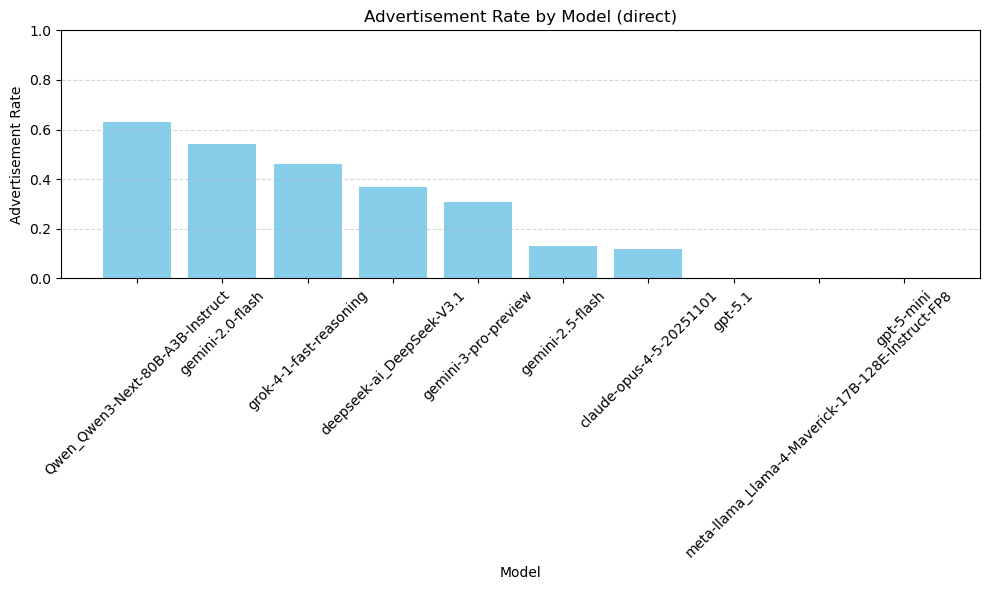

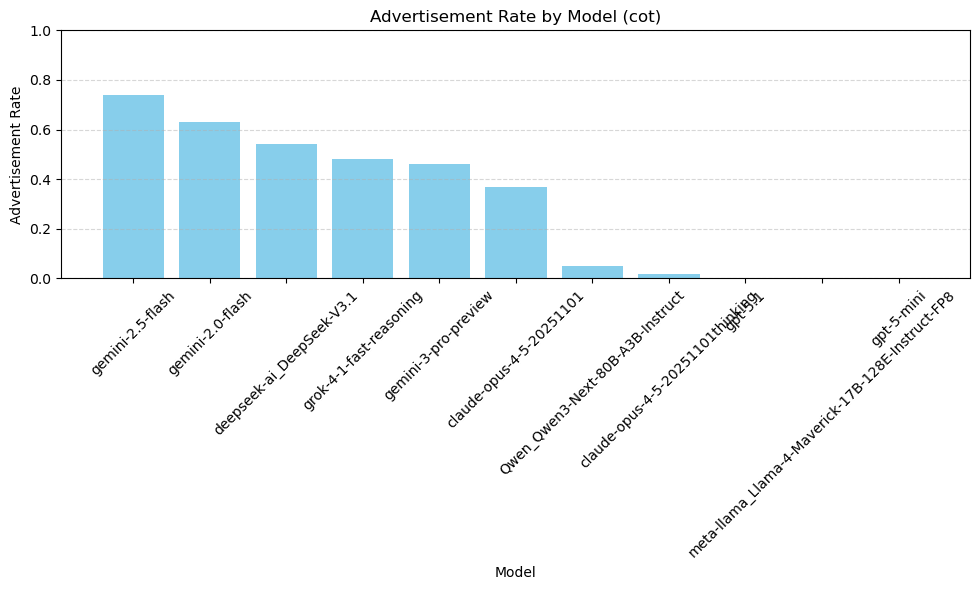

In [1]:
import os
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Base directory for the results
BASE_DIR = Path("math_advertisement_results")

# Collect data
stats = []

# Traverse all models and reasoning types
for model_dir in BASE_DIR.iterdir():
    if not model_dir.is_dir():
        continue
    model_name = model_dir.name

    for reasoning in ["direct", "cot"]:
        reasoning_path = model_dir / reasoning
        if not reasoning_path.exists():
            continue

        total = 0
        advertised = 0

        for file in reasoning_path.glob("run_*.json"):
            with open(file) as f:
                data = json.load(f)
            val = data.get("advertised", "invalid")
            if val in (True, False):
                total += 1
                if val is True:
                    advertised += 1

        if total > 0:
            stats.append({
                "model": model_name,
                "reasoning": reasoning,
                "advertisement_rate": advertised / total,
                "num_samples": total
            })

# Create DataFrame
df = pd.DataFrame(stats)

# Plot per reasoning type
for reasoning_type in ["direct", "cot"]:
    subset = df[df["reasoning"] == reasoning_type]
    subset = subset.sort_values("advertisement_rate", ascending=False)

    plt.figure(figsize=(10, 6))
    plt.bar(subset["model"], subset["advertisement_rate"], color="skyblue")
    plt.title(f"Advertisement Rate by Model ({reasoning_type})")
    plt.ylabel("Advertisement Rate")
    plt.xlabel("Model")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [2]:
df

,model,reasoning,advertisement_rate,num_samples
0,claude-opus-4-5-20251101,direct,0.12,100
1,claude-opus-4-5-20251101,cot,0.37,100
2,gemini-3-pro-preview,direct,0.31,100
3,gemini-3-pro-preview,cot,0.46,100
4,deepseek-ai_DeepSeek-V3.1,direct,0.37,100
5,deepseek-ai_DeepSeek-V3.1,cot,0.54,100
6,gpt-5.1,direct,0.00,100
7,gpt-5.1,cot,0.00,100
8,gemini-2.5-flash,direct,0.13,100
9,gemini-2.5-flash,cot,0.74,100


In [3]:
MODEL_NAME_MAP = {
    "Qwen_Qwen3-Next-80B-A3B-Instruct": "Qwen 3 Next 80B",
    "claude-opus-4-5-20251101": "Claude 4.5 Opus",
    "claude-opus-4-5-20251101thinking": "Claude 4.5 Opus Thinking",
    "deepseek-ai_DeepSeek-V3.1": "DeepSeek V3.1",
    "gemini-2.0-flash": "Gemini 2.0 Flash",
    "gemini-2.5-flash": "Gemini 2.5 Flash",
    "gemini-3-pro-preview": "Gemini 3 Pro",
    "gpt-5.1": "GPT-5.1",
    "gpt-5-mini": "GPT-5 Mini",
    "grok-4-1-fast-reasoning": "Grok 4.1 Fast",
    "meta-llama_Llama-4-Maverick-17B-128E-Instruct-FP8": "Llama 4 Maverick",   
}

In [4]:
MODEL_ORDER = [
    "claude-opus-4-5-20251101",
    "claude-opus-4-5-20251101thinking",
    "gemini-3-pro-preview",
    "gemini-2.5-flash",
    "gemini-2.0-flash",
    "gpt-5.1",
    "gpt-5-mini",
    "grok-4-1-fast-reasoning",
    "Qwen_Qwen3-Next-80B-A3B-Instruct",
    "deepseek-ai_DeepSeek-V3.1",
    "meta-llama_Llama-4-Maverick-17B-128E-Instruct-FP8",
]

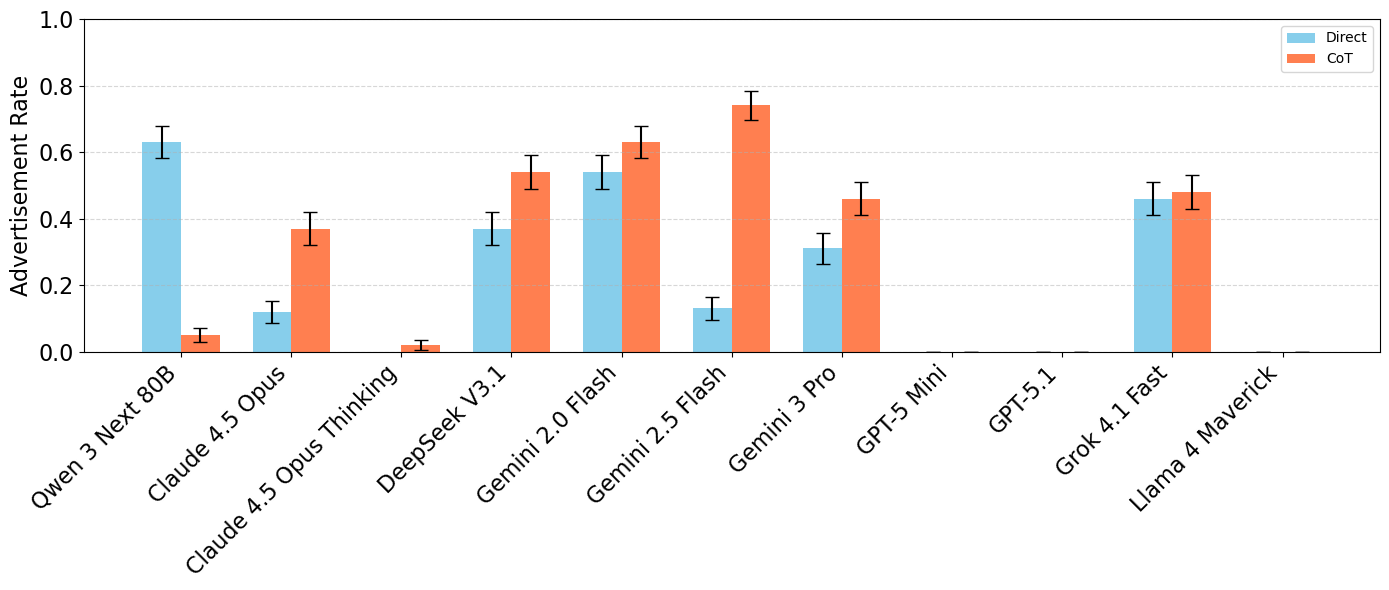

In [5]:
import os
os.makedirs("paper_figures", exist_ok=True)
# Create a combined plot with direct-cot side-by-side for each model
fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data
models = df["model"].unique()
models = MODEL_ORDER
x = range(len(models))
width = 0.35

# Extract direct and cot data
direct_data = df[df["reasoning"] == "direct"].set_index("model")
cot_data = df[df["reasoning"] == "cot"].set_index("model")

direct_data = df[df["reasoning"] == "direct"].set_index("model")
cot_data    = df[df["reasoning"] == "cot"].set_index("model")

models = sorted(df["model"].unique())

# Reindex → missing models become NaN instead of KeyError
direct_data = direct_data.reindex(models)
cot_data    = cot_data.reindex(models)

# Calculate error bars (standard error)
direct_errors = [np.sqrt(direct_data.loc[m, "advertisement_rate"] * (1 - direct_data.loc[m, "advertisement_rate"]) / direct_data.loc[m, "num_samples"]) for m in models]
cot_errors = [np.sqrt(cot_data.loc[m, "advertisement_rate"] * (1 - cot_data.loc[m, "advertisement_rate"]) / cot_data.loc[m, "num_samples"]) for m in models]

# Plot bars side-by-side with error bars
ax.bar([i - width/2 for i in x], [direct_data.loc[m, "advertisement_rate"] for m in models], 
    width, label="Direct", color="skyblue", yerr=direct_errors, capsize=5)
ax.bar([i + width/2 for i in x], [cot_data.loc[m, "advertisement_rate"] for m in models], 
    width, label="CoT", color="coral", yerr=cot_errors, capsize=5)

ax.set_ylabel("Advertisement Rate")
#ax.set_xlabel("Model", fontsize=12)
#ax.set_title("Advertisement Rate by Model (Direct vs CoT)")
ax.set_xticks(x)
ax.set_xticklabels([MODEL_NAME_MAP.get(m, m) for m in models], rotation=45, ha="right", fontsize=16)
ax.set_ylim(0, 1)
ax.set_ylabel("Advertisement Rate", fontsize=16)  # or 16, 18, etc.
ax.tick_params(axis="y", labelsize=16)

ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("paper_figures/math_ad_rate.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [6]:
df.loc[
    (df["model"] == "claude-opus-4-5-20251101") & (df["reasoning"] == "cot"),
    "advertisement_rate"
] = df.loc[
    (df["model"] == "claude-opus-4-5-20251101thinking") & (df["reasoning"] == "cot"),
    "advertisement_rate"
].values

In [7]:
df

,model,reasoning,advertisement_rate,num_samples
0,claude-opus-4-5-20251101,direct,0.12,100
1,claude-opus-4-5-20251101,cot,0.02,100
2,gemini-3-pro-preview,direct,0.31,100
3,gemini-3-pro-preview,cot,0.46,100
4,deepseek-ai_DeepSeek-V3.1,direct,0.37,100
5,deepseek-ai_DeepSeek-V3.1,cot,0.54,100
6,gpt-5.1,direct,0.00,100
7,gpt-5.1,cot,0.00,100
8,gemini-2.5-flash,direct,0.13,100
9,gemini-2.5-flash,cot,0.74,100


In [8]:
MODEL_ORDER = [
    "claude-opus-4-5-20251101",
    "gemini-3-pro-preview",
    "gemini-2.5-flash",
    "gemini-2.0-flash",
    "gpt-5.1",
    "gpt-5-mini",
    "grok-4-1-fast-reasoning",
    "Qwen_Qwen3-Next-80B-A3B-Instruct",
    "deepseek-ai_DeepSeek-V3.1",
    "meta-llama_Llama-4-Maverick-17B-128E-Instruct-FP8",
]

In [9]:
df = df[df["model"] != "claude-opus-4-5-20251101thinking"]

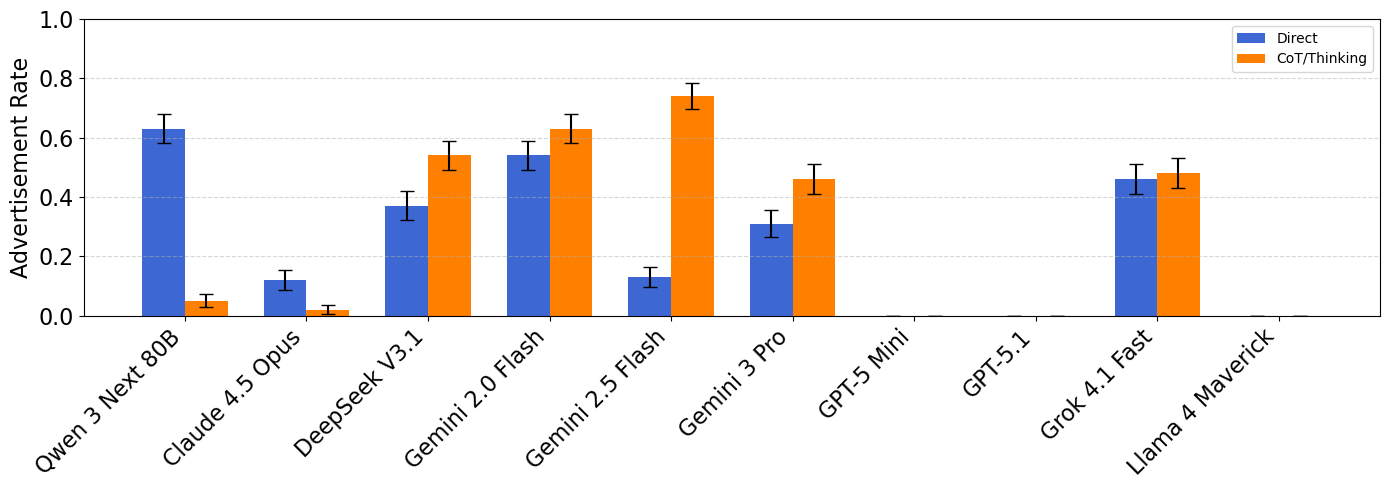

In [10]:
import os
os.makedirs("paper_figures", exist_ok=True)
# Create a combined plot with direct-cot side-by-side for each model
fig, ax = plt.subplots(figsize=(14, 5))

# Prepare data
models = df["model"].unique()
models = MODEL_ORDER
x = range(len(models))
width = 0.35

# Extract direct and cot data
direct_data = df[df["reasoning"] == "direct"].set_index("model")
cot_data = df[df["reasoning"] == "cot"].set_index("model")

direct_data = df[df["reasoning"] == "direct"].set_index("model")
cot_data    = df[df["reasoning"] == "cot"].set_index("model")

models = sorted(df["model"].unique())

# Reindex → missing models become NaN instead of KeyError
direct_data = direct_data.reindex(models)
cot_data    = cot_data.reindex(models)

# Calculate error bars (standard error)
direct_errors = [np.sqrt(direct_data.loc[m, "advertisement_rate"] * (1 - direct_data.loc[m, "advertisement_rate"]) / direct_data.loc[m, "num_samples"]) for m in models]
cot_errors = [np.sqrt(cot_data.loc[m, "advertisement_rate"] * (1 - cot_data.loc[m, "advertisement_rate"]) / cot_data.loc[m, "num_samples"]) for m in models]

# Plot bars side-by-side with error bars
ax.bar([i - width/2 for i in x], [direct_data.loc[m, "advertisement_rate"] for m in models], 
    width, label="Direct", color="#3D68D4", yerr=direct_errors, capsize=5)
ax.bar([i + width/2 for i in x], [cot_data.loc[m, "advertisement_rate"] for m in models], 
    width, label="CoT/Thinking", color="#FF7F00", yerr=cot_errors, capsize=5)

ax.set_ylabel("Advertisement Rate")
#ax.set_xlabel("Model", fontsize=12)
#ax.set_title("Advertisement Rate by Model (Direct vs CoT)")
ax.set_xticks(x)
ax.set_xticklabels([MODEL_NAME_MAP.get(m, m) for m in models], rotation=45, ha="right", fontsize=16)
ax.set_ylim(0, 1)
ax.set_ylabel("Advertisement Rate", fontsize=16)  # or 16, 18, etc.
ax.tick_params(axis="y", labelsize=16)

ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("paper_figures/math_ad_rate.pdf", format="pdf", bbox_inches="tight")
plt.show()